# Step 1 — Laplacian Eigenmaps on Karate Club

This notebook implements the classical **Laplacian Eigenmaps** spectral embedding
(Belkin & Niyogi, 2003) on the Karate Club graph. This serves as the baseline
against which we will compare learned autoencoder embeddings.

**Contents:**
1. Compute the normalized Laplacian and its eigenvectors
2. 2-D spectral embedding and community visualization
3. Clustering quality (NMI, accuracy) vs ground truth
4. Effect of embedding dimension on community separability
5. Comparison of unnormalized vs normalized Laplacian embeddings

In [1]:
import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.datasets import KarateClub
from torch_geometric.utils import to_dense_adj, to_networkx
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, accuracy_score

np.random.seed(42)

# Load data
dataset = KarateClub()
data = dataset[0]
A = to_dense_adj(data.edge_index).squeeze(0).numpy()
labels = data.y.numpy()
n = data.num_nodes

print(f"Nodes: {n}, Edges: {data.num_edges // 2}, Labels: {np.unique(labels)}")

Nodes: 34, Edges: 78, Labels: [0 1 2 3]


## 1. Laplacian Eigenmap Embedding Function

Given an adjacency matrix $A$, compute the graph Laplacian and return the
eigenvectors corresponding to the $d$ smallest **nonzero** eigenvalues.

- **Unnormalized:** $L = D - A$, solve $L v = \lambda v$
- **Normalized:** $\mathcal{L} = I - D^{-1/2} A D^{-1/2}$, solve $\mathcal{L} v = \lambda v$

In [2]:
def laplacian_eigenmap(A, n_components=2, normalized=True, tol=1e-10):
    """Compute Laplacian Eigenmap embedding.
    
    Returns:
        eigvals: eigenvalues for the selected components
        Z: embedding matrix of shape (n, n_components)
    """
    degrees = A.sum(axis=1)
    D = np.diag(degrees)
    L = D - A

    if normalized:
        inv_sqrt_deg = np.where(degrees > 0, 1.0 / np.sqrt(degrees), 0.0)
        D_inv_sqrt = np.diag(inv_sqrt_deg)
        L = D_inv_sqrt @ L @ D_inv_sqrt

    eigvals, eigvecs = np.linalg.eigh(L)
    order = np.argsort(eigvals)
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Skip trivial zero eigenvalue(s)
    nontrivial = np.where(eigvals > tol)[0]
    if len(nontrivial) < n_components:
        raise ValueError("Not enough non-trivial eigenvectors.")

    idx = nontrivial[:n_components]
    return eigvals[idx], eigvecs[:, idx]

## 2. 2-D Spectral Embedding

Selected eigenvalues: [0.1323 0.287 ]


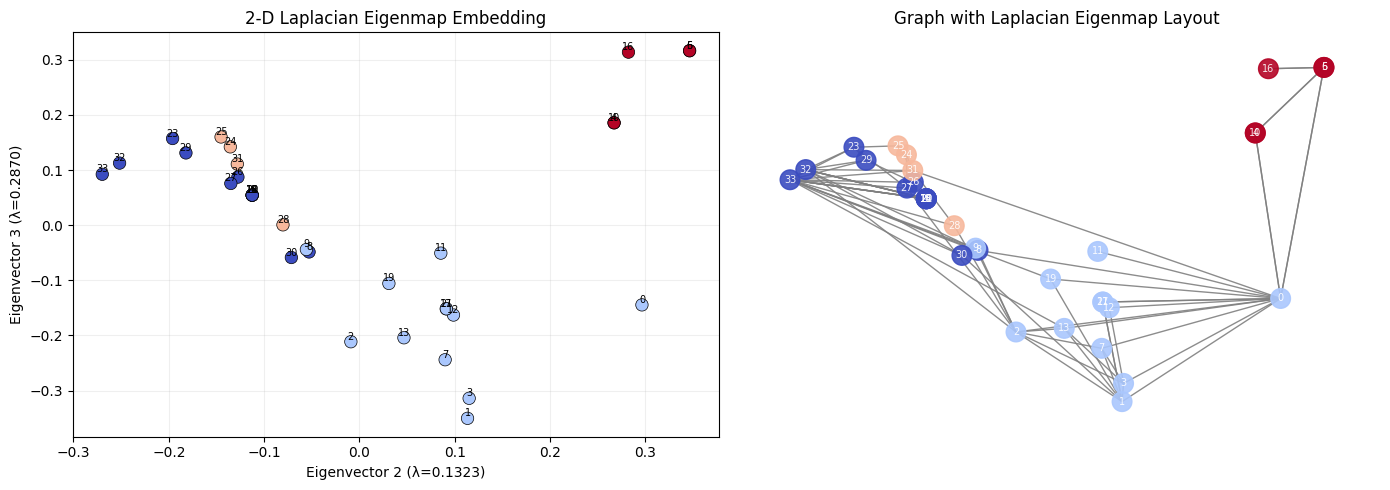

In [3]:
eigvals_2d, Z_2d = laplacian_eigenmap(A, n_components=2, normalized=True)
print(f"Selected eigenvalues: {eigvals_2d.round(4)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot of 2-D embedding
ax = axes[0]
scatter = ax.scatter(Z_2d[:, 0], Z_2d[:, 1], c=labels, cmap="coolwarm", s=80,
                     edgecolor="k", linewidth=0.5, zorder=3)
for i in range(n):
    ax.annotate(str(i), (Z_2d[i, 0], Z_2d[i, 1]), fontsize=7, ha="center", va="bottom")
ax.set_xlabel(f"Eigenvector 2 (λ={eigvals_2d[0]:.4f})")
ax.set_ylabel(f"Eigenvector 3 (λ={eigvals_2d[1]:.4f})")
ax.set_title("2-D Laplacian Eigenmap Embedding")
ax.grid(alpha=0.2)

# Graph drawn using LE coordinates as layout
ax = axes[1]
G = to_networkx(data, to_undirected=True)
pos_le = {i: Z_2d[i] for i in range(n)}
nx.draw_networkx(G, pos=pos_le, node_color=labels, cmap="coolwarm",
                 node_size=200, font_size=7, font_color="white",
                 edge_color="gray", alpha=0.9, ax=ax)
ax.set_title("Graph with Laplacian Eigenmap Layout")
ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Community Recovery via K-Means

Apply K-Means (k=2) on the spectral embedding and measure clustering quality
against the ground-truth faction labels.

In [4]:
def clustering_metrics(Z, labels, n_clusters=2):
    """Run KMeans and return NMI and best-permutation accuracy."""
    km = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
    pred = km.fit_predict(Z)
    nmi = normalized_mutual_info_score(labels, pred)
    # Try both label assignments (since KMeans labels are arbitrary)
    acc = max(accuracy_score(labels, pred),
              accuracy_score(labels, 1 - pred))
    return pred, nmi, acc

pred_2d, nmi_2d, acc_2d = clustering_metrics(Z_2d, labels)

print(f"2-D Laplacian Eigenmap + KMeans:")
print(f"  NMI:      {nmi_2d:.4f}")
print(f"  Accuracy: {acc_2d*100:.1f}%")

# Show which nodes are misclassified
best_pred = pred_2d if accuracy_score(labels, pred_2d) >= accuracy_score(labels, 1 - pred_2d) else 1 - pred_2d
misclassified = np.where(best_pred != labels)[0]
print(f"  Misclassified nodes: {misclassified.tolist() if len(misclassified) > 0 else 'None'}")

2-D Laplacian Eigenmap + KMeans:
  NMI:      0.4952
  Accuracy: 38.2%
  Misclassified nodes: [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 16, 17, 19, 21, 24, 25, 28, 31]


## 4. Effect of Embedding Dimension

How does community recovery change as we vary the number of Laplacian eigenvectors used?

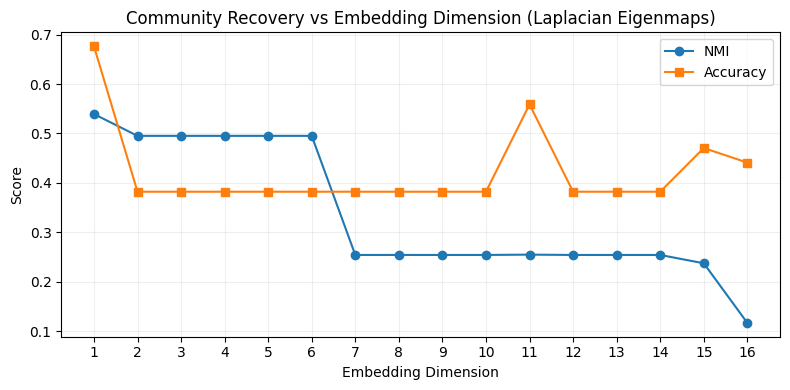

In [5]:
dims = range(1, 17)
nmis = []
accs = []

for d in dims:
    _, Z_d = laplacian_eigenmap(A, n_components=d, normalized=True)
    _, nmi_d, acc_d = clustering_metrics(Z_d, labels)
    nmis.append(nmi_d)
    accs.append(acc_d)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(dims), nmis, "o-", label="NMI", color="tab:blue")
ax.plot(list(dims), accs, "s-", label="Accuracy", color="tab:orange")
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel("Score")
ax.set_title("Community Recovery vs Embedding Dimension (Laplacian Eigenmaps)")
ax.legend()
ax.set_xticks(list(dims))
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 5. Normalized vs Unnormalized Laplacian

Compare embeddings from the two Laplacian variants.

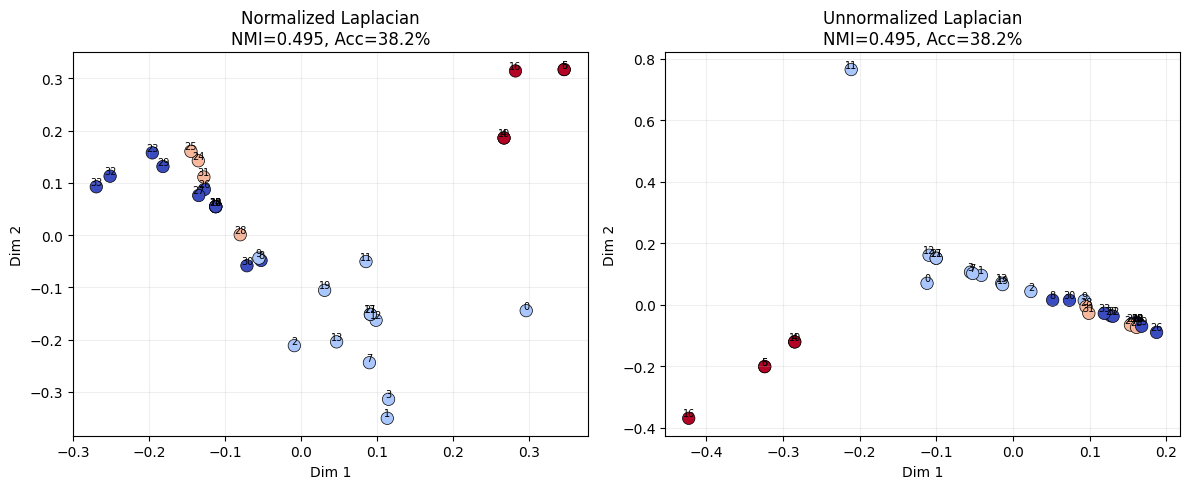

In [6]:
_, Z_norm = laplacian_eigenmap(A, n_components=2, normalized=True)
_, Z_unnorm = laplacian_eigenmap(A, n_components=2, normalized=False)

_, nmi_norm, acc_norm = clustering_metrics(Z_norm, labels)
_, nmi_unnorm, acc_unnorm = clustering_metrics(Z_unnorm, labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, Z, title, nmi, acc in [
    (axes[0], Z_norm, "Normalized", nmi_norm, acc_norm),
    (axes[1], Z_unnorm, "Unnormalized", nmi_unnorm, acc_unnorm),
]:
    ax.scatter(Z[:, 0], Z[:, 1], c=labels, cmap="coolwarm", s=80,
              edgecolor="k", linewidth=0.5)
    for i in range(n):
        ax.annotate(str(i), (Z[i, 0], Z[i, 1]), fontsize=7, ha="center", va="bottom")
    ax.set_title(f"{title} Laplacian\nNMI={nmi:.3f}, Acc={acc*100:.1f}%")
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 6. Within- vs Between-Community Distances

Quantify how well the embedding separates the two factions.

In [7]:
from scipy.spatial.distance import pdist, squareform

D_emb = squareform(pdist(Z_norm))

mask_0 = labels == 0
mask_1 = labels == 1

within_0 = D_emb[np.ix_(mask_0, mask_0)][np.triu_indices(mask_0.sum(), k=1)].mean()
within_1 = D_emb[np.ix_(mask_1, mask_1)][np.triu_indices(mask_1.sum(), k=1)].mean()
between = D_emb[np.ix_(mask_0, mask_1)].mean()

print(f"Within community 0 avg distance: {within_0:.4f}")
print(f"Within community 1 avg distance: {within_1:.4f}")
print(f"Between communities avg distance: {between:.4f}")
print(f"Separation ratio (between / avg within): {between / ((within_0 + within_1) / 2):.4f}")

Within community 0 avg distance: 0.1043
Within community 1 avg distance: 0.1585
Between communities avg distance: 0.3390
Separation ratio (between / avg within): 2.5802


## Summary

**Key findings (to be filled after running):**
- The Fiedler vector alone achieves high community recovery accuracy.
- The normalized Laplacian tends to produce more balanced embeddings.
- These spectral results serve as the baseline for the autoencoder in notebook `02`.